---
title: "Pie Charts"
subtitle: "DS 2023 | Communicating with Data"
---

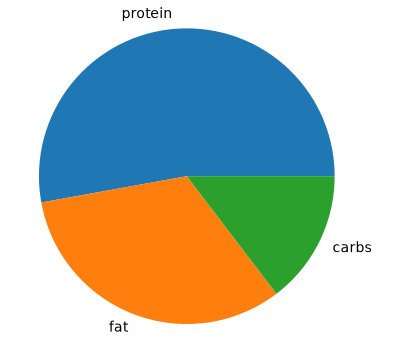

## Overview

A pie chart is a circular graph used to display the relative magnitudes of a **numeric measurement** variable associated with a **grouping** variable. 

For example, a grouping variable might be the types of food eaten during a day and the associated measurement might be number of calories. 

The entire circle represents sum total of value of a given measurement, e.g. the total number of calories consumed in a day.

Each slice represents the contribution to the total by one of the group's categoroes. 

The area of the wedge is proportional to the magnitude of the measurement value for the category.

Pie charts typically use **color** to distinguish the different slices.

## Use Cases

- Viewing grouping variables whose domains constitute **some whole**, for example food types and diets, expenses and budgets, or investment options and portfolios.

- Representing **aggregate** values for the domain of a grouping variable, where each slice represents a unique value and an associated statistic, such as its count or mean.

> [!note] The categories in the grouping variable domain should be **disjoint**, **exhaustive**, and relatively **few** in number.
> - _Disjoint_ means that an obseration can have only one category value.
> - _Exhaustive_ means that an observation my have one category value.
> - The meaning of _few in number_ varies, but the idea is that there should not be so many slices on the pie that they can't be visually distinguished.

## A simple example

Let's create some imaginary data based the already described example &mdash; someone's nutrient consumption in the course of a day by food type and measured in grams.

The **pie** will represent the total number of grams of food consumed by some person in a given day. 

Each **slice** will represent on of the main nutrient groups &mdash; protein, fat, and carbohydrates.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
diet = pd.Series({
    'protein': 65,
    'fat': 40,
    'carbs': 18
})

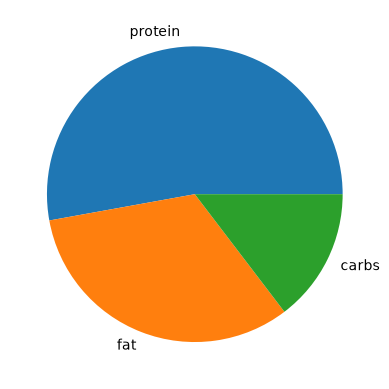

In [4]:
diet.plot.pie()
plt.show()

With this pie chart, we can see clearly the relative amounts consumed from each food type.

The person appears to be on a low-carb diet.

## A more complex example

Let's now look at a classic data set &mdash; the Titanic data set.

This data set shows the survival rate of passengers on the ill-fated vessel that sank in 1912.

It consists almost entirely of nominal data for $1316$ passengers.

These data are ideal for pie charts because: 

1. Many variables represent exhaustive and exclusive groups, e.g. `class` and `sex`.
2. The number of values per feature is small.

We can use pie charts to display each feature's composition.

In [5]:
titanic = sns.load_dataset('titanic')
titanic.sample(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
499,0,3,male,24.0,0,0,7.7958,S,Third,man,True,NaN,Southampton,no,True
720,1,2,female,6.0,0,1,33.0000,S,Second,child,False,NaN,Southampton,yes,False
852,0,3,female,9.0,1,1,15.2458,C,Third,child,False,NaN,Cherbourg,no,False
354,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
415,0,3,female,NaN,0,0,8.0500,S,Third,woman,False,NaN,Southampton,no,True
766,0,1,male,NaN,0,0,39.6000,C,First,man,True,NaN,Cherbourg,no,True
525,0,3,male,40.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
670,1,2,female,40.0,1,1,39.0000,S,Second,woman,False,NaN,Southampton,yes,False
494,0,3,male,21.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
500,0,3,male,17.0,0,0,8.6625,S,Third,man,True,NaN,Southampton,no,True


For convenience, let's create a new feature `age_group` based on `age` to show if the person is an adult or child.

The converts the numberic variable `age` into a binary group.

In [10]:
titanic['age_group'] = np.where(
    (titanic['age'] >= 18)
    | titanic['who'].isin(['man','woman']), 
    'adult', 'child')

In addition, we are only interested in a subset of categorial columns, those that meet the criteria specified above, so we select those.

In [12]:
my_cols = ['sex', 'age_group', 'class','survived']
titanic = titanic[my_cols]
titanic.sample(10)

,sex,age_group,class,survived
837,male,adult,Third,0
878,male,adult,Third,0
178,male,adult,Second,0
662,male,adult,First,0
94,male,adult,Third,0
308,male,adult,Second,0
436,female,adult,Third,0
203,male,adult,Third,0
107,male,adult,Third,1
503,female,adult,Third,0


Now let's create a pie chart for each of these features.

To do this, we create a list of **aggregate** data frames, one associated with each feature.

This is necessary because the slices of a pie chart must represent distinct categories.

In [13]:
dfs = {}
for col in my_cols:
    dfs[col] = titanic.value_counts(col)

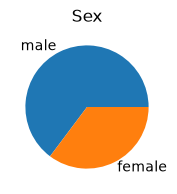

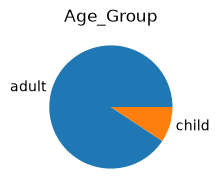

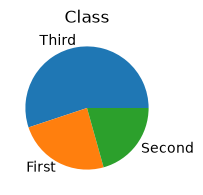

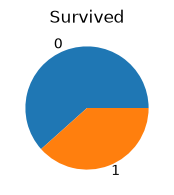

In [14]:
for col in dfs:
    df = dfs[col]
    df.plot.pie(title=col.title(), figsize=(2,2))
    plt.show()

A better way to show all for four pies is with a grid of subplots.

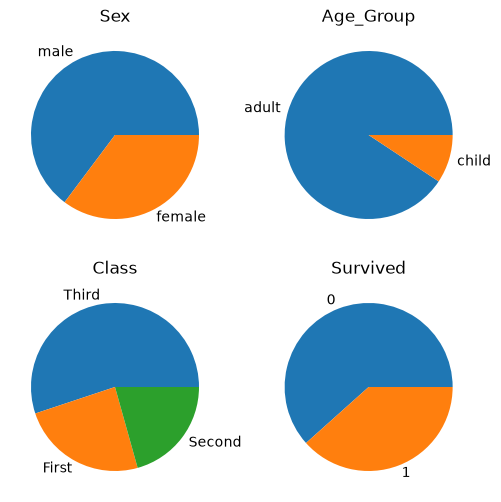

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(6,6))
for i, col in enumerate(titanic.columns):
    c = i % 2
    r = i // 2
    df = titanic.value_counts(col)
    df.plot.pie(title=col.title(), ax=ax[r,c])
plt.show()

## Combining groups

We can see that there are two kinds of group variables in the Titanic data set: 

- those that define the _social category_ of each person

- one that defines the _fate_ each person. 

The first set may be thought of as **input** values and the second as the **output**.

Let's group the data by social category and get the value counts of the survival variable. 

This produces a data frame where the categorical features form the index and the survival feature is projected onto the column axis.

In [16]:
titanic_vc = titanic[my_cols].value_counts().unstack(fill_value=0)
titanic_vc.columns = ['no','yes']
titanic_vc

no  yes
sex    age_group class           
male   adult     First    77   42
                 Second   91    8
                 Third   281   38
       child     First     0    3
                 Second    0    9
                 Third    19    9
female adult     First     2   89
                 Second    6   60
                 Third    58   56
       child     First     1    2
                 Second    0   10
                 Third    14   16

We can use the survival rate data to compute a rough probability estimate `s_rate`  as follows.

In [18]:
titanic_vc['s_rate'] = titanic_vc.div(titanic_vc.sum(axis=1), axis=0).yes
titanic_vc.sort_values('s_rate')

no  yes    s_rate
sex    age_group class                     
male   adult     Second   91    8  0.080742
                 Third   281   38  0.119078
       child     Third    19    9  0.317781
       adult     First    77   42  0.351897
female adult     Third    58   56  0.489120
       child     Third    14   16  0.524017
                 First     1    2  0.545455
male   child     First     0    3  0.750000
female adult     Second    6   60  0.896739
male   child     Second    0    9  0.900000
female child     Second    0   10  0.909091
       adult     First     2   89  0.967622

In this form, the table lets us ask questions like: 

> "If a passenger was a first class adult male, what was their chance of surviving?"

Since these data are exhaustive, exclusive, and relatively few, we can use a pie chart to visualize the probabilities.

> [!caution] Although the categories are exhaustive and exclusive in this example, the probabilities represented by the pie do not sum to $1$.
> 
> This is because each value is a conditional probability given a combination of categorical features.

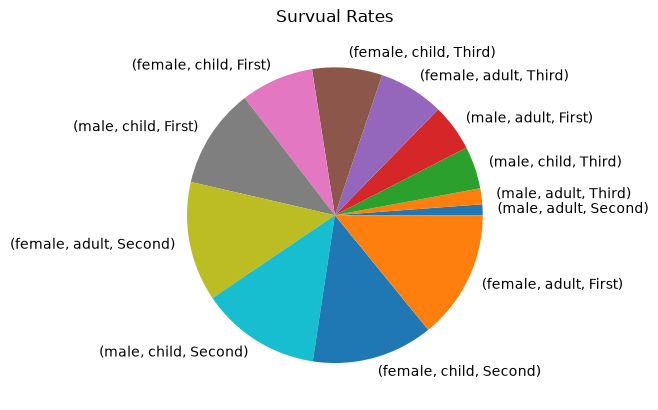

In [19]:
titanic_vc.s_rate.sort_values().plot.pie(title="Survual Rates")
plt.show()

How readable is this chart? Does it easily show which category combinations had the highest and lowest survival rates? 

It turns out that pie charts become less useful as the number of categories increases.

In such cases, it is often better to fall back onto a bar chart.

The one below clearly shows which categories had the highest and lowest survival rates.

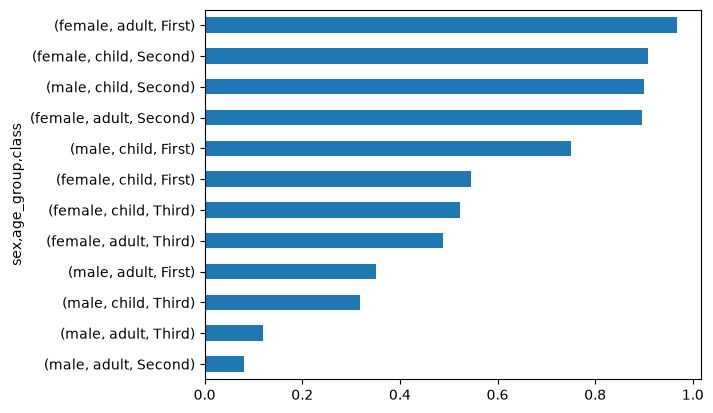

In [20]:
ax = titanic_vc.s_rate.sort_values().plot.barh()
plt.show()

> [!note] Be careful not to read too much into the survival rates of the first and second class children.
>
> Their total numbers are much smaller than the other categories.
> 
> Below, we visualize the fate of the adult passengers.

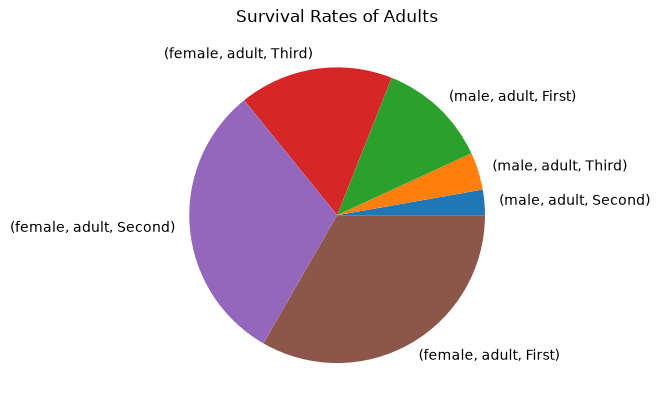

In [22]:
(
    titanic_vc
        .query("age_group == 'adult'")
        .s_rate
        .sort_values()
        .plot
        .pie(title="Survival Rates of Adults")
)
plt.show()

## Improving display

Panda's pie charts come with some useful arguments to improve their display.

These are:

- `autopct`: to label slides with their associated percentages.
- `explode`: to pull out a slide for emphasis.
- `starting`: to orient the pie so that the first cut appears at the degree of your choice.

To use the `autopct` argument, you can pass a standard Python formatting string to autopct to control decimal places.

- `autopct='%1.1f%%'`: Displays one decimal place (e.g., $12.5\%$).
- `autopct='%1.2f%%'`: Displays two decimal places (e.g., $12.50\%$).
- `autopct='%1.0f%%'`: Rounds to the nearest whole integer (e.g., $13\%$)

> [!note] THe `autopct` argument here is using Python's `%` formatting style. To learn more about it, check out this [article](https://www.geeksforgeeks.org/python/string-formatting-in-python/).

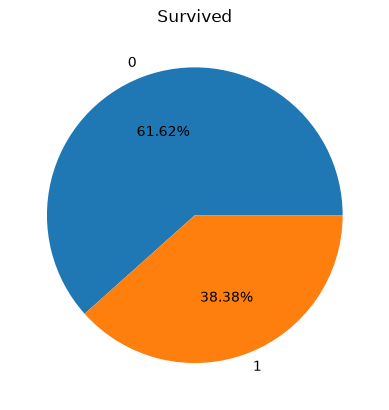

In [25]:
feature_name = 'survived'
dfs[feature_name].plot.pie(autopct='%1.2f%%', title=feature_name.title())
plt.show()

Here's how you can pull out a slide to emphasize it.

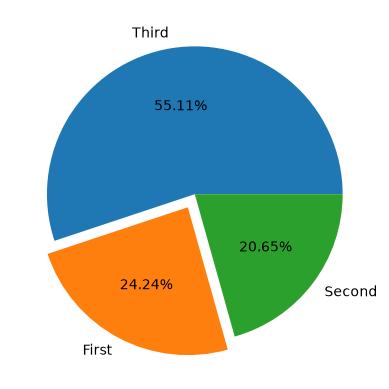

In [26]:
explode_tuple = (0, 0.1, 0) 
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple)
plt.show()

Note that you can pull out more than one slice.

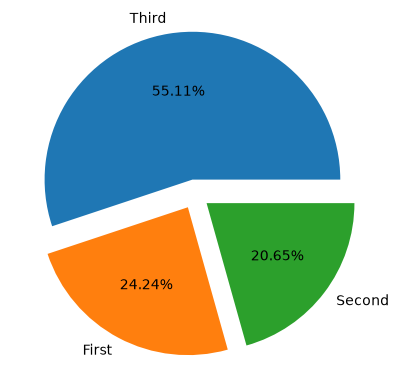

In [27]:
explode_tuple = (0.1, 0.1, 0.1) 
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple)
plt.show()

Finally, here's how you can reorient the pie using `startangle`.

Here we set the value to $90\degree$, which corresponses to the <tt>12:00</tt> position of a clock.

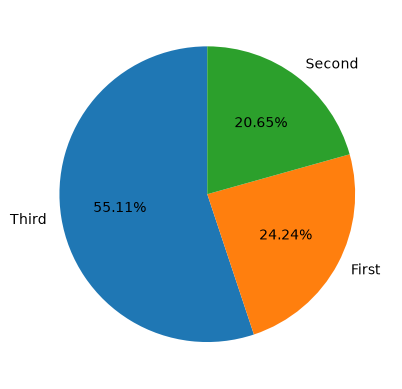

In [28]:
dfs['class'].plot.pie(autopct='%1.2f%%', startangle=90)
plt.show()